# Circuit Basics
Qiskit provides the basic building blocks necessary to program quantum computers.  
The fundamental unit of Qiskit is the quantum circuit.  
A basic workflow using Qiskit consists of two stages :  
$BUILD :$ allows you build a differnt circuits that represent the problem you are solving.  
$RUN :$ allows you to run them on different backends.  
after the jobs have been run, the data is collected and postprocessed depending on the desire output.

In [100]:
import numpy as np 
from qiskit import QuantumCircuit

## Building the circuit
The basic element needed for your first program is the QuantumCircuit. We begin by creating a $QuantumCircuit$ comprised of three qubits.

In [102]:
# Create a Quantum Circuit acting on a quantum register of three qubits
qc = QuantumCircuit(3)

After you create the circuit with its registers, you can add gates ("operations") to manipulate the registers. Below is an example of a quantum circuit that makes a three-qubit GHZ state
$$\ket{\psi} = \frac{1}{\sqrt{2}} (\ket{000} + \ket{111})$$
To create such a state, we start with a three-qubit quantum register. By default, each qubit in the register is initialized to $\ket{0}$  

In [104]:
# Add a H gate on qubit 0, putting this qubit in superposition.
qc.h(0)
# Add a CX (CNOT) gate on control qubit 0 and target qubit 1, putting
# the qubits in a Bell state.
qc.cx(0,1)
# Add a CX (CNOT) gate on control qubit 0 and target qubit 2, putting
# the qubits in a GHZ state.
qc.cx(0,2)

## Visualize Circuit
You can visualize your circuit using Qiskit $QuantumCircuit.draw()$, which plots the circuit in the form found in many textbooks.

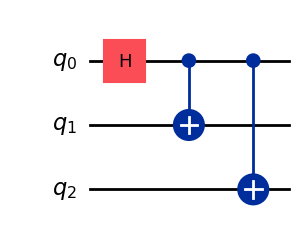

In [106]:
# qc.draw('text')       # terminal
qc.draw('mpl')        # matplotlib (Jupyter)
# qc.draw('latex')      # LaTeX diagram

In this circuit, the qubits are put in order, with qubit zero at the top and qubit two at the bottom. The circuit is read left to right (meaning that gates that are applied earlier in the circuit show up further to the left)

In [108]:
# Inspect the circuit
print(qc.num_qubits)  # number of qubits
print(qc.depth())     # circuit depth (layers of gates)
print(qc.count_ops()) 

3
3
OrderedDict([('cx', 2), ('h', 1)])


## Simulating circuits
To simulate a circuit we use the quant_info module in Qiskit. This simulator returns the quantum state, which is a complex vector of dimensions $2^n$, where $n$ is the number of qubits (so be careful using this as it will quickly get too large to run on your machine).

There are two stages to the simulator. The first is to set the input state and the second to evolve the state by the quantum circuit.

In [110]:
from qiskit.quantum_info import Statevector

# Set the initial state of the simulator to the ground state using from_int 
state = Statevector.from_int(0, 2**3)

# Evolve the state by the quantum circuit 
state = state.evolve(qc) 

#draw using latex
state.draw('latex')

<IPython.core.display.Latex object>

In [112]:
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

Qiskit also provides a visualization toolbox to allow you to view the state.  
Below, we use the visualization function to plot the qsphere and a hinton representing the real and imaginary components of the state density matrix 

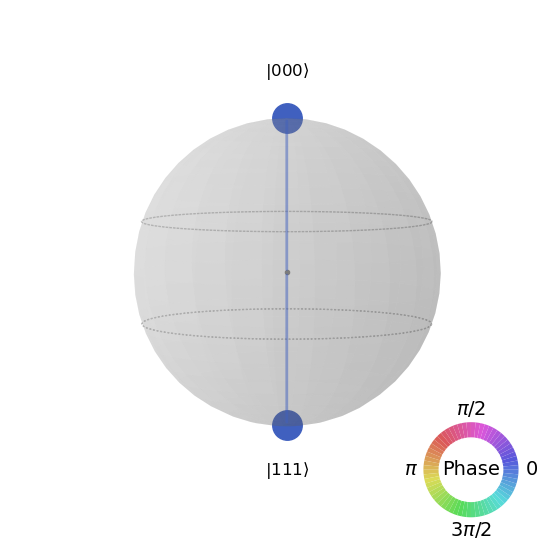

In [74]:
state.draw('qsphere')

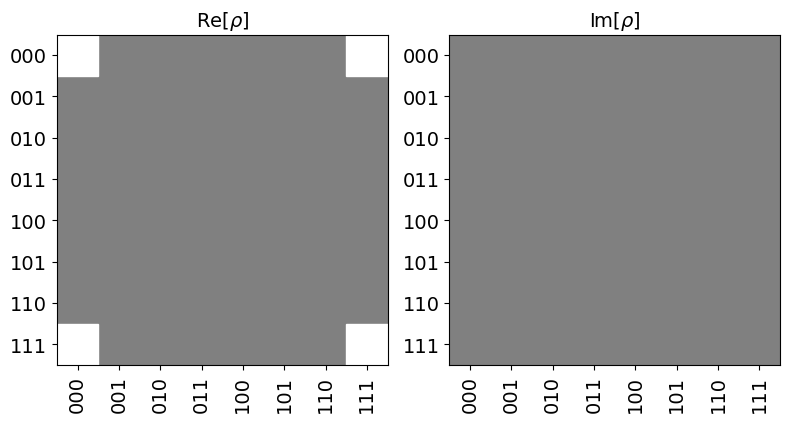

In [76]:
state.draw('hinton')

## Unitary representation of a circuit
Qiskit's quant_info module also has an operator method which can be used to make a unitary operator for the circuit. This calculates the $2^n X  2^n$matrix representing the quantum circuit.

In [86]:
from qiskit.quantum_info import Operator
unitary = Operator(qc)

# Show the results
print(unitary.data)

[[ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.70710678+0.j -0.70710678+0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j  0.70710678+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j -0.70710678+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j
   

## OpenQASM backend
The simulators above are useful because they provide information about the state output by the ideal circuit and the matrix representation of the circuit. However, a real experiment terminates by measuring each qubit (usually in the computational $\ket{0}$, $\ket{1}$ basis). Without measurement, we cannot gain information about the state. Measurements cause the quantum system to collapse into classical bits.

For example, suppose we make independent measurements on each qubit of the three-qubit GHZ state
$$\ket{\psi} = \frac{1}{\sqrt{2}} (\ket{000} + \ket{111})$$
and let $xyz$denote the bitstring that results. Recall that, under the qubit labeling used by Qiskit, $x$ would correspond to the outcome on qubit 2, $y$ to the outcome on qubit 1, and $z$ to the outcome on qubit 0.

Recall the probability of obtaining outcome $xyz$ is given by
$$Pr(xyz) = |\bra{xyz}\ket{\psi}|^2$$
and as such for the GHZ state probability of obtaining 000 or 111 are both 1/2.  
To simulate a circuit that includes measurement, we need to add measurements to the original circuit above, and use a different Aer backend.

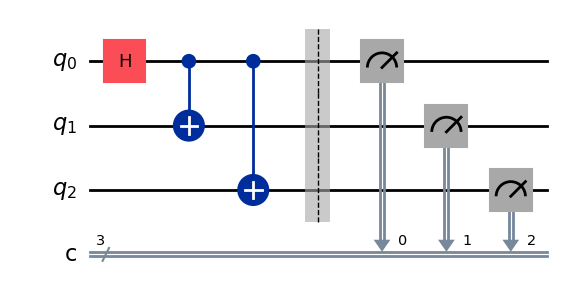

In [124]:
# Create a Quantum Circuit
meas = QuantumCircuit(3, 3) 
meas.barrier(range(3))
# map the quantum measurement to the classical bits 
meas.measure(range(3), range(3))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before) 
# as compose must put a smaller circuit into a larger one.
circ = meas.compose(qc, range(3), front=True)
#drawing the circuit
circ.draw('mpl')

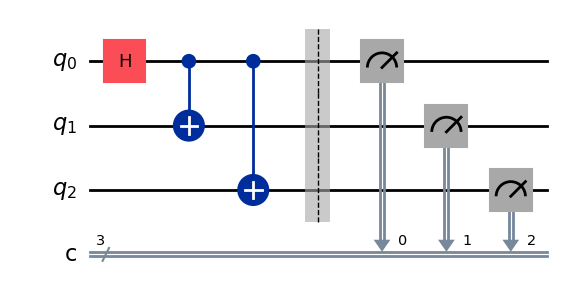

In [128]:
# Simple circuit 
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 3)   # 3 qubits + 3 classical bits in one circuit

qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.barrier()                # visual separator before measurement
qc.measure([0, 1, 2], [0, 1, 2])

qc.draw('mpl')              # shows everything

To simulate this circuit, we use the qasm_simulator in Qiskit Aer. Each run of this circuit will yield either the bitstring 000 or 111. To build up statistics about the distribution of the bitstrings (to, e.g., estimate $Pr(000)$), we need to repeat the circuit many times. The number of times the circuit is repeated can be specified in the execute function, via the shots keyword.

In [133]:
# Adding the transpiler to reduce the circuit to QASM instructions
# supported by the backend 
# transpile converts your ideal abstract circuit into a circuit that a specific backend can actually run. (simple gates)
from qiskit import transpile

# Use AerSimulator
from qiskit_aer import AerSimulator

backend = AerSimulator()

# First we have to transpile the quantum circuit 
# to the low-level QASM instructions used by the 
# backend
qc_compiler = transpile(circ, backend)

# Execute the circuit on the qasm simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default. 
job_sim = backend.run(qc_compiler, shots = 1024)

In [135]:
# Grab the results from the job. 
results = job_sim.result()

Once you have a result object, you can access the counts via the function get_counts(circuit). This gives you the aggregated binary outcomes of the circuit you submitted.

In [138]:
counts = results.get_counts(qc_compiler)
print(counts)

{'111': 521, '000': 503}


Approximately 50 percent of the time, the output bitstring is 000. Qiskit also provides a function plot_histogram, which allows you to view the outcomes.

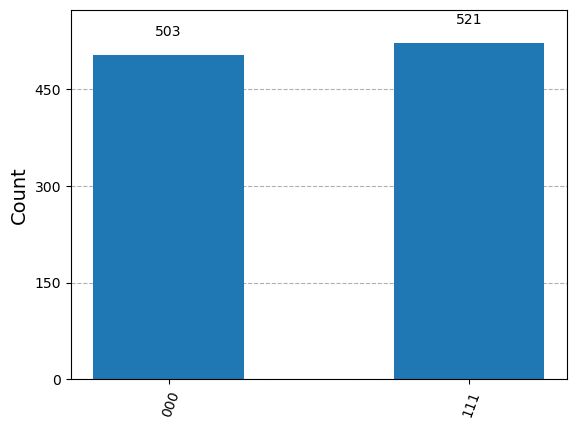

In [143]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

## Aer's simulation methods
This is the most important thing to understand about Aer it has multiple simulation engines, each suited for different tasks:
| Method | Needs measure? | Output | Best for |
| :--- | :--- | :--- | :--- |
| **statevector** | No | Amplitudes | Debugging, math |
| **QASM sampling** | Yes | Counts histogram | Realistic experiments |
| **density_matrix** | Optional | $\rho$ matrix | Noise, mixed states |
| **unitary** | No | Matrix $U$ | Verify gate logic |

In [151]:
from qiskit_aer import Aer

# Run the quantum circuit on a statevector simulator backend 
backend = Aer.get_backend('statevector_simulator')

Now that we have chosen the backend, it's time to compile and run the quantum circuit. In Qiskit we provide the run method for this. run returns a job object that encapsulates information about the job submitted to the backend.

In [170]:
# Create a Quantum Program for execution 
job_1 = backend.run(qc)

When you run a program, a job object is made that has the following two useful methods: job.status() and job.result(), which return the status of the job and a result object, respectively.

In [172]:
status = job_1.status()
result = job_1.result()

In [161]:
print(status)

JobStatus.DONE


The results object contains the data and Qiskit provides the method result.get_statevector(circ) to return the state vector for the quantum circuit.

In [174]:
outputstate = result.get_statevector(qc, decimals=3)
print(outputstate)

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


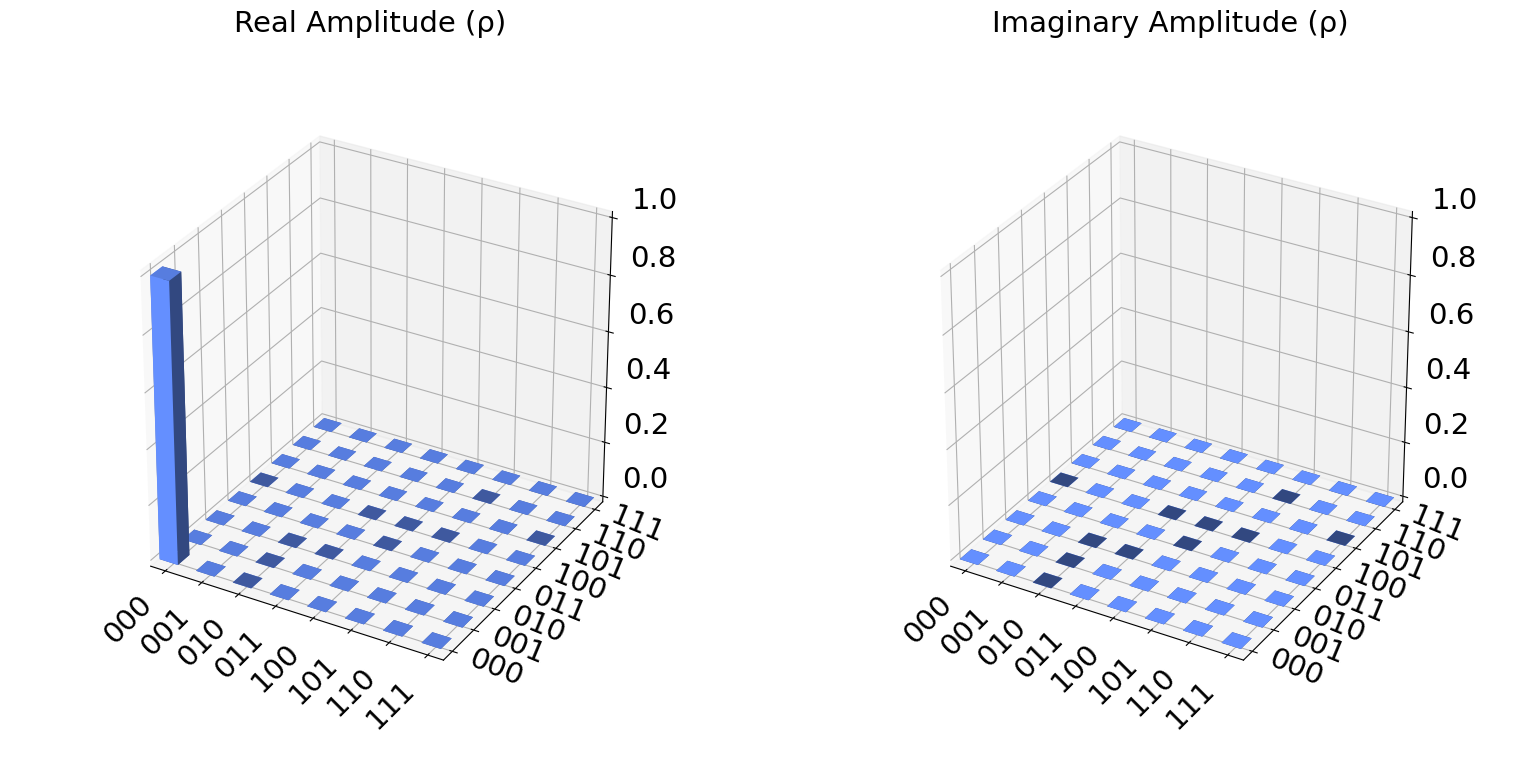

In [176]:
from qiskit.visualization import plot_state_city
plot_state_city(outputstate)